# Business Sales Performance Analytics

## Future Interns – Data Science & Analytics Internship

### Objective
Analyze business sales data to identify revenue trends, top-performing products, profitable categories, and regional performance. Provide actionable business insights and recommendations based on the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
import os

print(os.listdir("data"))

['Superstore.csv']


In [7]:
df = pd.read_csv("data/Superstore.csv", encoding="latin1")


In [8]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 9994
Number of Columns: 21


In [9]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df["Month"] = df["Order Date"].dt.month_name()
df["Year"] = df["Order Date"].dt.year

In [16]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2015


In [17]:
print("Total Sales: $", round(df["Sales"].sum(),2))

Total Sales: $ 2297200.86


In [18]:
print("Total Profit: $", round(df["Profit"].sum(),2))

Total Profit: $ 286397.02


In [19]:
print("Total Orders:", df["Order ID"].nunique())

Total Orders: 5009


In [20]:
print("Unique Customers:", df["Customer ID"].nunique())

Unique Customers: 793


In [21]:
print("Average Sales:", round(df["Sales"].mean(),2))

Average Sales: 229.86


Visualization 1: Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

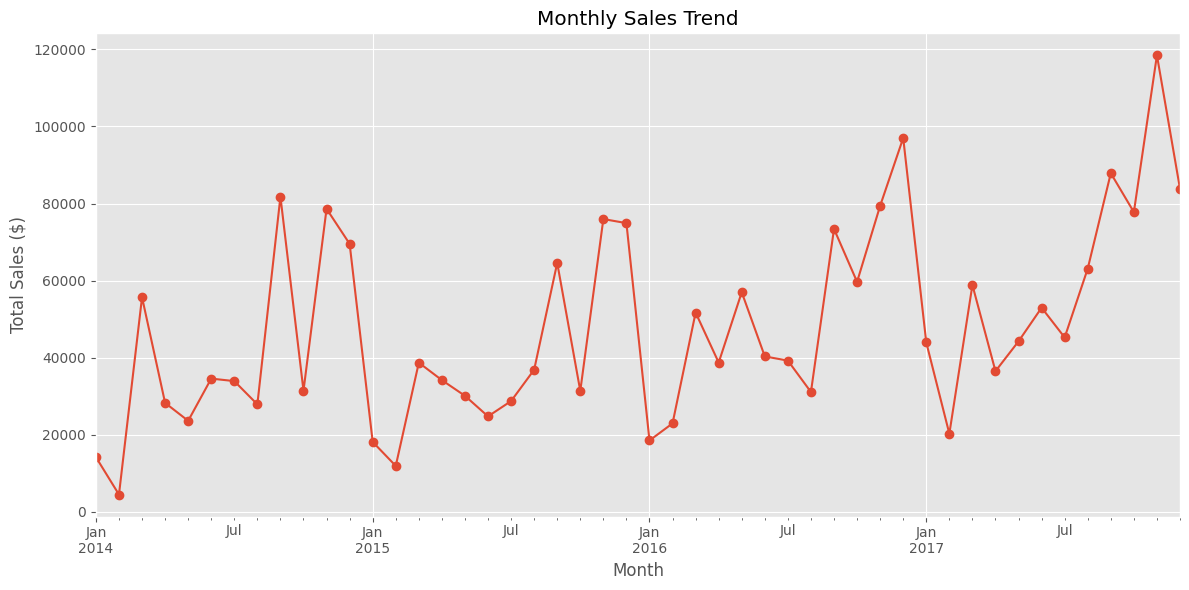

In [23]:
plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/monthly_sales_trend.png", dpi=300)
plt.show()

## 📈 Monthly Sales Trend
### Insights
- Sales fluctuate throughout the observed period.
- Some months experience noticeable peaks, indicating seasonal demand or promotional events.
- Understanding these trends helps businesses plan inventory and marketing strategies.

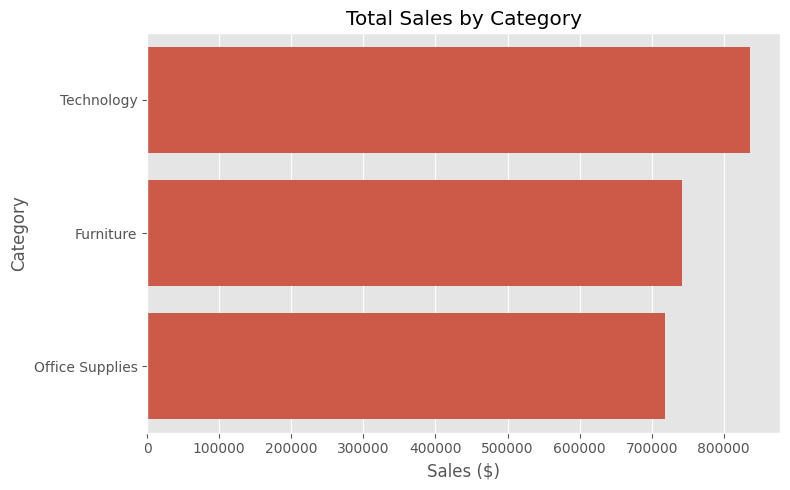

In [24]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)
plt.title("Total Sales by Category")
plt.xlabel("Sales ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("images/category_sales.png", dpi=300)
plt.show()

## 📦 Sales by Category
### Insights
- Compare which category contributes the highest revenue.
- Lower-performing categories may require promotional efforts or product expansion.

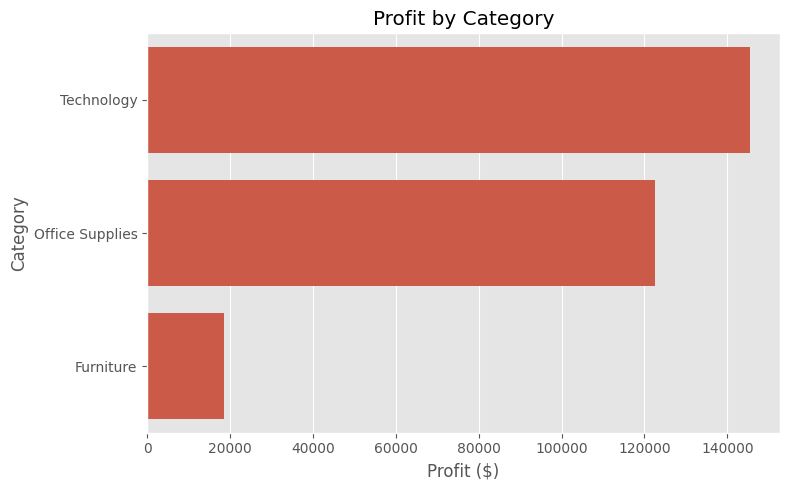

In [25]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)
plt.title("Profit by Category")
plt.xlabel("Profit ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("images/profit_by_category.png", dpi=300)
plt.show()

### Insights
• Technology is the most profitable category.
• Office Supplies also contribute strong profits.
• Furniture generates comparatively low profit despite high sales, suggesting thinner profit margins.

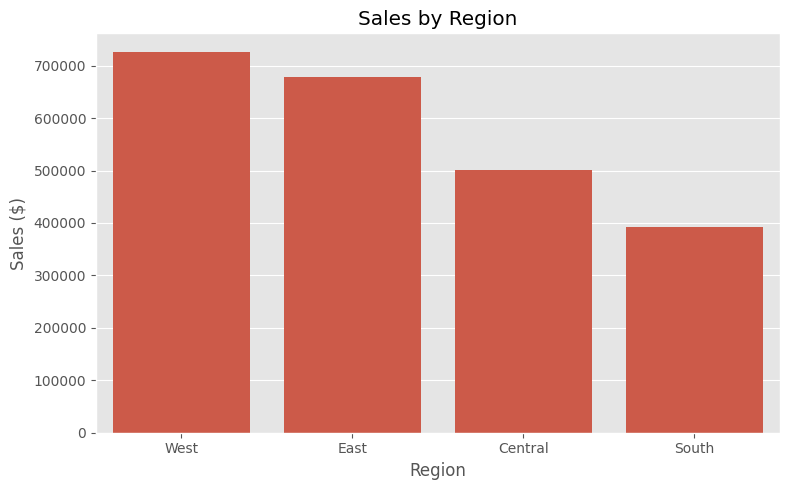

In [26]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("images/sales_by_region.png", dpi=300)
plt.show()

### Insights
• The West region generated the highest sales.
• The East region followed closely.
• The South region recorded the lowest sales and may require targeted marketing efforts.

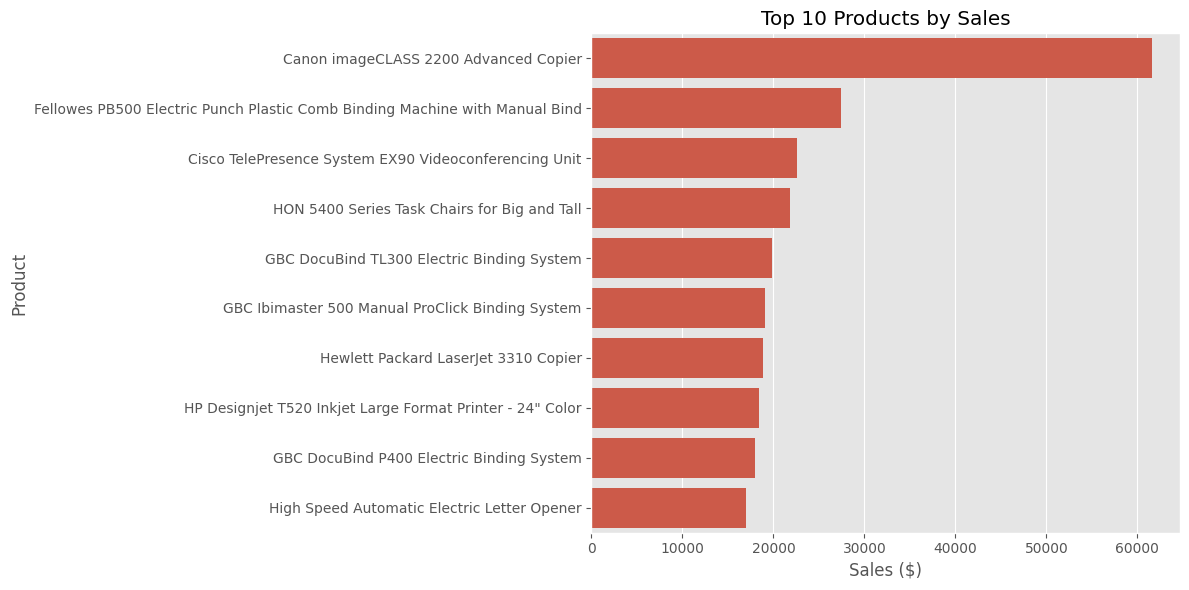

In [27]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("images/top_10_products.png", dpi=300)
plt.show()

### Insights
• The Canon imageCLASS 2200 Advanced Copier is the highest-selling product.
• The top-selling products are primarily technology and office equipment.
• Maintaining inventory of these products can help maximize revenue.

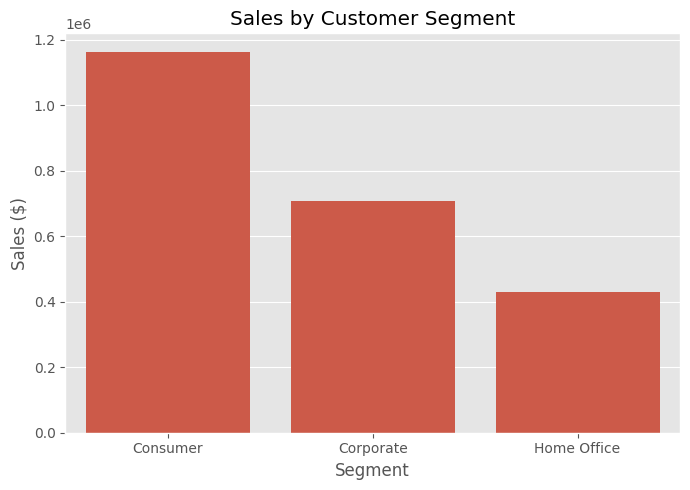

In [28]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")

plt.tight_layout()

plt.savefig("images/sales_by_segment.png", dpi=300)

plt.show()

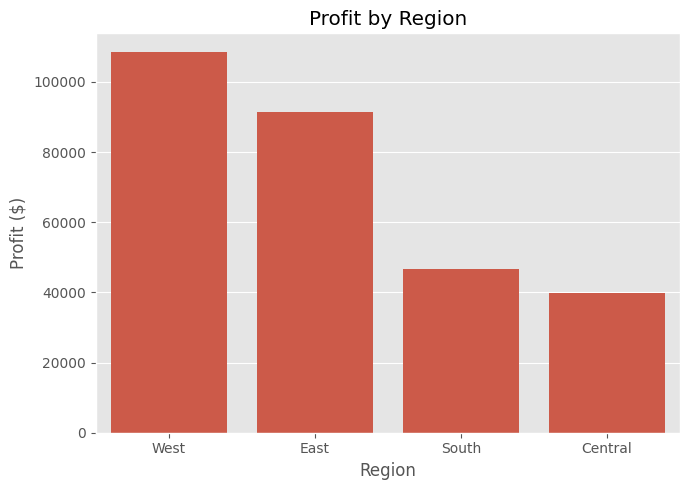

In [29]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig("images/profit_by_region.png", dpi=300)

plt.show()

# Business Recommendations

- Focus marketing campaigns on the Technology category, as it leads both sales and profit.
- Investigate why Furniture has high sales but relatively low profit margins.
- Allocate additional inventory to top-selling products to avoid stock shortages.
- Develop strategies to improve sales in the South region through localized promotions.
- Use historical monthly sales trends to plan inventory and seasonal campaigns more effectively.